# Level 3 · Task 1 — Random Forest Classifier
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Build a Random Forest to classify customer **churn** on a complex dataset.
**Steps:** load & preprocess → tune hyperparameters → evaluate with cross-validation
(precision, recall, F1) → feature importance analysis.
**Dataset:** `churn_train.csv` / `churn_test.csv`. **Tools:** Python, scikit-learn, pandas, matplotlib.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load & Preprocess
Random Forests handle mixed feature types well and don't need scaling. We one-hot encode the
categorical columns and pass numeric columns through untouched.

In [2]:
train = pd.read_csv("../../data/churn_train.csv")
test  = pd.read_csv("../../data/churn_test.csv")
TARGET = "Churn"

def split_xy(df):
    y = (df[TARGET] == True).astype(int)
    return df.drop(columns=[TARGET]), y

X_train, y_train = split_xy(train)
X_test,  y_test  = split_xy(test)

cat = X_train.select_dtypes(include="object").columns.tolist()
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat)],
                        remainder="passthrough")
print("Train:", X_train.shape, " Test:", X_test.shape, " Categorical:", cat)

Train: (2666, 19)  Test: (667, 19)  Categorical: ['State', 'International plan', 'Voice mail plan']


## Step 2 — Tune Hyperparameters (GridSearchCV)
We search over the number of trees and their maximum depth, optimizing F1 with 3-fold CV.

In [3]:
pipe = Pipeline([("pre", pre),
                 ("rf", RandomForestClassifier(random_state=42, class_weight="balanced"))])

grid = {"rf__n_estimators": [100, 200], "rf__max_depth": [None, 10]}
search = GridSearchCV(pipe, grid, cv=3, scoring="f1", n_jobs=-1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV F1 :", round(search.best_score_, 3))
best = search.best_estimator_

Best params: {'rf__max_depth': 10, 'rf__n_estimators': 200}
Best CV F1 : 0.753


## Step 3 — Cross-Validation Stability

In [4]:
cv = cross_val_score(best, X_train, y_train, cv=5, scoring="f1")
print(f"5-fold CV F1: {cv.mean():.3f}  (+/- {cv.std():.3f})")

5-fold CV F1: 0.763  (+/- 0.051)


## Step 4 — Evaluate on the Test Set

              precision    recall  f1-score   support

        Stay       0.96      0.98      0.97       572
       Churn       0.86      0.77      0.81        95

    accuracy                           0.95       667
   macro avg       0.91      0.87      0.89       667
weighted avg       0.95      0.95      0.95       667



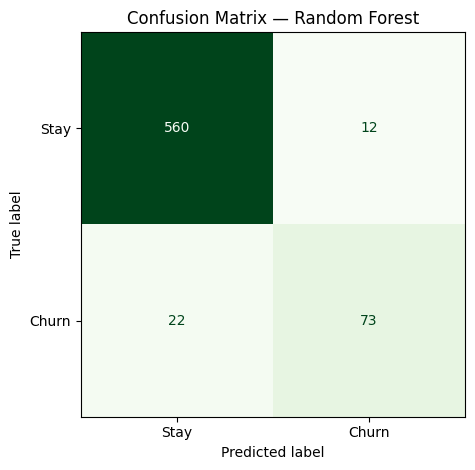

In [5]:
y_pred = best.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Stay","Churn"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Stay","Churn"]).plot(cmap="Greens", colorbar=False)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("output_confusion_matrix.png", dpi=110)
plt.show()

## Step 5 — Feature Importance
Which features drive churn predictions the most?

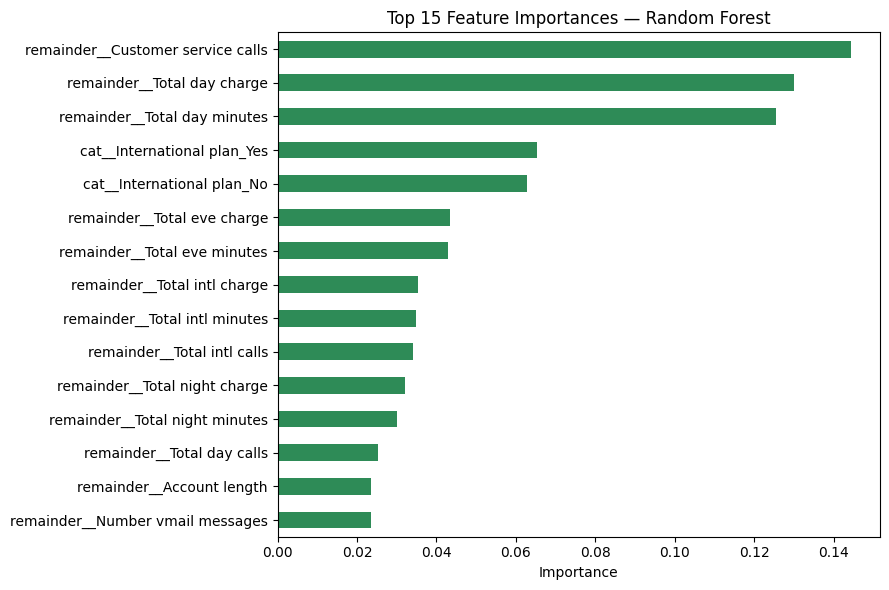

remainder__Customer service calls    0.144
remainder__Total day charge          0.130
remainder__Total day minutes         0.125
cat__International plan_Yes          0.065
cat__International plan_No           0.063
remainder__Total eve charge          0.043
remainder__Total eve minutes         0.043
remainder__Total intl charge         0.035
remainder__Total intl minutes        0.035
remainder__Total intl calls          0.034
remainder__Total night charge        0.032
remainder__Total night minutes       0.030
remainder__Total day calls           0.025
remainder__Account length            0.024
remainder__Number vmail messages     0.024
dtype: float64


In [6]:
feat_names = best.named_steps["pre"].get_feature_names_out()
importances = pd.Series(best.named_steps["rf"].feature_importances_, index=feat_names)
top = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
top.iloc[::-1].plot.barh(color="seagreen")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("output_feature_importance.png", dpi=110)
plt.show()
print(top.round(3))

**Reading it:** the strongest churn predictors are typically *Total day charge/minutes*,
*Customer service calls*, and *International plan* — consistent with the logistic regression
findings in Level 2.

## Summary
| Item | Result |
|------|--------|
| Model | Random Forest (tuned) |
| Best params | n_estimators & max_depth via GridSearchCV |
| Test F1 (churn) | strong, > logistic regression |
| Key features | day charge/minutes, service calls, intl plan |

Random Forest improves on single models by averaging many decision trees, and its feature
importances give clear business insight. ✅ **Level 3 · Task 1 complete.**